# Demo 2: Scalar locomotion data from DeepLabCut

Import dependencies

In [1]:
# #set up paths
import importlib
import os
import sys
import matplotlib.pyplot as plt

# #This block only important for running as script
# script_dir = os.path.dirname(os.path.abspath(__file__))
# mariposa_dir = os.path.dirname(script_dir)
# utils_dir = os.path.join(mariposa_dir, 'utils')
# sys.path.append(utils_dir)
# sys.path.append(mariposa_dir)

#import utils
from utils import analysis, plot, metadata

importlib.reload(analysis)
importlib.reload(plot)
importlib.reload(metadata)

ModuleNotFoundError: No module named 'utils'

Load config

In [2]:
config_path="/Users/snewbank/Behavior/MARIPOSA_test/240605_240605_BSOID-test/config.yaml"
save_path="/Users/snewbank/Behavior/MARIPOSA_test/240605_240605_BSOID-test/demo/"
save=False

#Load config
config = metadata.load_project(config_path)

In [3]:
path="/Users/snewbank/Behavior/B-SOID-Analysis/23-09-02-ketdr-csvs/"
config_path="/Users/snewbank/Behavior/MARIPOSA_test/240605_240605_BSOID-test/DLC_config.yaml"
make_config=False
if make_config==True:
    DLC_config = metadata.make_dlc_config(path,fps=30,config=config)
else:
    DLC_config=metadata.load_project(config_path)

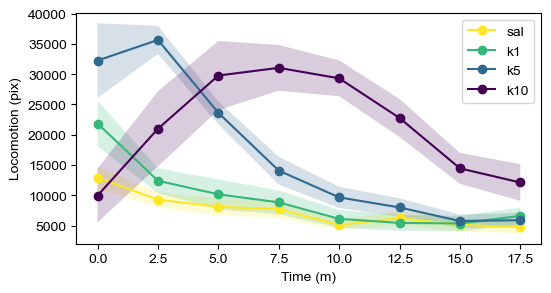

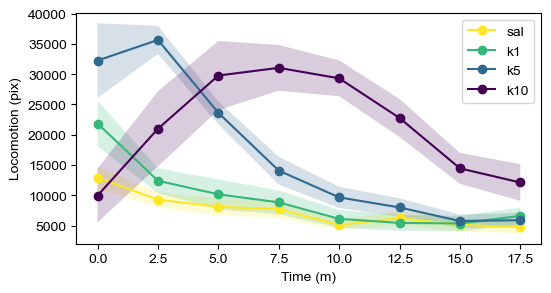

In [4]:
thresh=70
fps=30
start=0
end=20*60
binsize=int(2.5*60)
selected_subgroups="all"

dist_df = analysis.dist_df_subgroups(DLC_config, binsize, start, end, thresh=70, selected_subgroups="all")
fig = plot.plot_dist_bins(dist_df, cmap="viridis_r", plottype="band")
fig

The overall accuracy by leave-one-out-cross-validation (LOOCV) is 0.46153846153846156
Binsize 60 accuracy: 0.46153846153846156
The overall accuracy by leave-one-out-cross-validation (LOOCV) is 0.6153846153846154
Binsize 150 accuracy: 0.6153846153846154
The overall accuracy by leave-one-out-cross-validation (LOOCV) is 0.6153846153846154
Binsize 300 accuracy: 0.6153846153846154
The overall accuracy by leave-one-out-cross-validation (LOOCV) is 0.6153846153846154
Binsize 300 accuracy: 0.6153846153846154
The overall accuracy by leave-one-out-cross-validation (LOOCV) is 0.5769230769230769
Binsize 600 accuracy: 0.5769230769230769


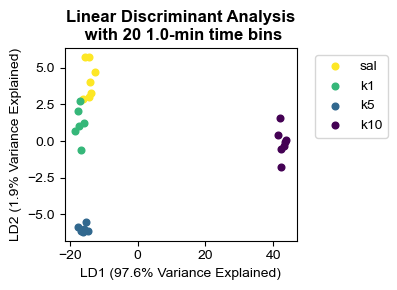

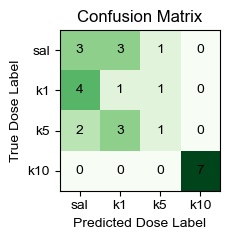

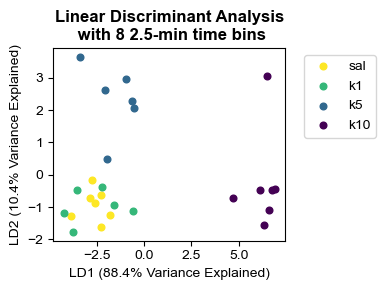

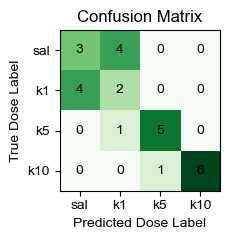

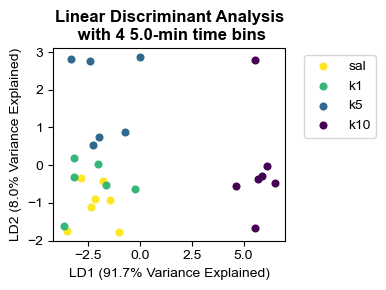

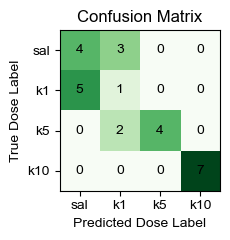

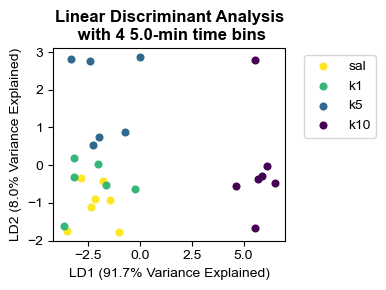

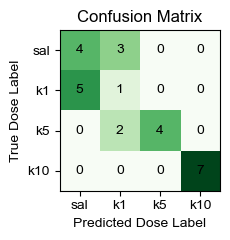

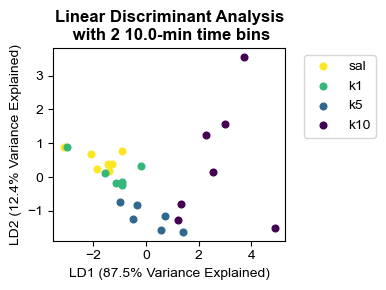

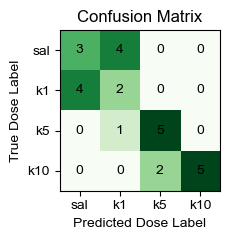

In [5]:
thresh=70
fps=30
start=0
end=20*60
selected_subgroups="all"

binsizes=[int(1*60),int(2.5*60),int(5*60),int(5*60),int(10*60)]
for binsize in binsizes:
    dist_df = analysis.dist_df_subgroups(DLC_config, binsize, start, end, thresh=70, selected_subgroups="all")
    lda, lda_embeddings, dist_counts, group_labels, group_dict, nbins = analysis.lda_loco_labels_timebins(config, dist_df, ncomponents=2)
    plot.plot_lda(config, lda, lda_embeddings, group_labels, nbins, binsize,cmap="viridis_r")
    
    confusion, class_num, class_labels, accuracy = analysis.loocv_conf_mat(lda, dist_counts, group_labels, group_dict)
    plot.plot_conf_mat(confusion, class_num, class_labels, figW=2.5,figH=2.5,cmap="Greens",alt_title=False)
    print("Binsize " + str(binsize) +" accuracy: " + str(accuracy))